# Fase 0a — Os dados

## O projeto em uma frase

Uma rede de varejo com 5 lojas e 20 produtos precisa **prever a demanda diária de cada item** para dimensionar sua reposição. Antes de qualquer modelo, é preciso entender os dados: o que são, como se organizam e o que faz a demanda subir e descer. É o que este notebook estabelece.

## Roteiro de leitura

Os notebooks são numerados na ordem em que devem ser lidos.

| # | notebook | pergunta |
|---|---|---|
| 01 | [Os dados](01_fase0a_osDados.ipynb) | O que são os dados e o que move a demanda? |
| 02 | [O custo do problema](02_fase0b_oCustoDoProblema.ipynb) | Quanto custa a ruptura, e quanto custa o estoque? |
| 03 | [O ciclo de reposição](03_fase0c_cicloDeReposicao.ipynb) | Por que acontece, e o que o modelo precisa prever? |
| 04 | [Conclusões da fase 0](04_fase0_conclusoes.ipynb) | *consolidação do entendimento* |
| 05 | [Trilha A — regressão linear](05_fase1a_regressaoLinear.ipynb) | Qual o piso, e o que o dado exige? |
| 06 | [Trilha B — gradient boosting](06_fase1b_gradientBoosting.ipynb) | Interações automáticas resolvem? |
| 07 | [Trilha C — rede neural](07_fase1c_redeNeural.ipynb) | Representação densa de categóricas resolve? |
| 08 | [Conclusões da fase 1](08_fase1_conclusoes.ipynb) | *comparação das três trilhas* |
| 09 | [Fase 2 — hiperparâmetros](09_fase2_hiperparametros.ipynb) | Quanto rende configurar bem o modelo escolhido? |
| 10 | [Conclusões finais](10_conclusoesFinais.ipynb) | *veredito do projeto* |

## Origem do dataset

| | |
|---|---|
| **Nome** | Retail Store Inventory and Demand Forecasting |
| **Autor** | Wavelet (usuário `atomicd` no Kaggle) |
| **Endereço** | [kaggle.com/datasets/atomicd/retail-store-inventory-and-demand-forecasting](https://www.kaggle.com/datasets/atomicd/retail-store-inventory-and-demand-forecasting) |
| **Licença** | Apache 2.0 |
| **Arquivo** | `sales_data.csv` — 6,3 MB, versão de 21/05/2025 |

O autor não coletou esses dados: **ele os gerou por simulação**. O conjunto revisa o [Retail Store Inventory Forecasting Dataset](https://www.kaggle.com/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset), de Anirudh Chauhan, corrigindo identificadores mal rotulados, acrescentando a variável `Epidemic` (para simular o varejo durante a pandemia de COVID-19) e substituindo a antiga previsão de demanda por uma coluna `Demand`. A finalidade declarada é servir de material de estudo para previsão de séries temporais.

Ser sintético importa: em dado simulado existem **relações impostas pelo gerador** que se confundem com descobertas. Este notebook identifica e quantifica quatro delas.

## O conceito central: demanda não é venda

> **Venda** (`Units Sold`) é o que a loja conseguiu vender. **Demanda** (`Demand`) é o que os clientes queriam comprar.

Os dois coincidem apenas quando há produto na prateleira. Esgotado o estoque, a venda cessa no limite físico, mas a demanda continua existindo na forma de cliente que sai sem comprar — evento chamado de **ruptura** (*stockout*), cuja diferença é a **venda perdida**.

Daí a escolha do alvo: quem decide reposição precisa estimar quanto o cliente vai querer, não quanto a prateleira vazia permitiu levar.

## Dicionário de variáveis

Ordenadas por **momento em que a informação passa a existir**, critério que decide quem pode ser preditor:

| coluna | tipo | descrição |
|---|---|---|
| `Date` | data | dia do registro |
| `Store ID` | texto | loja (S001…S005) |
| `Product ID` | texto | código do produto (P0001…P0020) |
| `Category` | texto | Groceries, Clothing, Electronics, Furniture, Toys |
| `Region` | texto | North, South, East, West |
| `Price` | número | preço praticado no dia |
| `Discount` | número | desconto aplicado, em % |
| `Promotion` | 0/1 | campanha promocional |
| `Competitor Pricing` | número | preço do item equivalente no concorrente |
| `Weather Condition` | texto | Sunny, Cloudy, Rainy, Snowy |
| `Seasonality` | texto | Winter, Spring, Summer, Autumn |
| `Epidemic` | 0/1 | período de epidemia |
| `Inventory Level` | número | estoque disponível no dia |
| `Units Sold` | número | unidades vendidas |
| `Units Ordered` | número | unidades pedidas ao fornecedor |
| **`Demand`** | **número** | **unidades demandadas — variável-alvo** |

As três colunas anteriores ao alvo só existem **depois** do dia encerrado. A seção 4 trata das consequências disso.

## 1. Carga e integridade

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

PALETA = "Set2"
SEQ = "Blues"

caminho = next(arq for pasta in [Path("."), Path("projeto"), Path("..")]
               for arq in sorted(pasta.glob("sales_data*.csv")))

nomes = {"Date": "data", "Store ID": "loja", "Product ID": "produto", "Category": "categoria",
         "Region": "regiao", "Inventory Level": "estoque", "Units Sold": "vendas",
         "Units Ordered": "pedidos", "Price": "preco", "Discount": "desconto",
         "Weather Condition": "clima", "Promotion": "promocao",
         "Competitor Pricing": "preco_concorrente", "Seasonality": "estacao",
         "Epidemic": "epidemia", "Demand": "demanda"}

vendas = pd.read_csv(caminho, parse_dates=["Date"]).rename(columns=nomes)
vendas["sku"] = vendas["loja"] + "-" + vendas["produto"]

print("Arquivo:", caminho, "|", vendas.shape[0], "linhas ×", vendas.shape[1] - 1, "colunas")
print("Período:", vendas["data"].min().date(), "a", vendas["data"].max().date(),
      f"({vendas['data'].nunique()} dias)")
print("Valores nulos:", int(vendas.isna().sum().sum()),
      "| Linhas duplicadas:", int(vendas.duplicated().sum()))
vendas.head(3)

Arquivo: sales_data (1).csv | 76000 linhas × 16 colunas
Período: 2022-01-01 a 2024-01-30 (760 dias)
Valores nulos: 0 | Linhas duplicadas: 0


,data,loja,produto,categoria,regiao,estoque,vendas,pedidos,preco,desconto,clima,promocao,preco_concorrente,estacao,epidemia,demanda,sku
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,S001-P0001
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,S001-P0002
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,S001-P0003


76.000 linhas, 760 dias sem falha, nenhum nulo e nenhuma duplicata. A ausência total de imperfeições é o **primeiro indício de origem sintética** — uma operação real teria feriado, produto descontinuado, falha de registro —, mas dispensa limpeza. Saber quantas linhas existem não diz o que cada uma representa: é o que a seção 2 estabelece.

## 2. Estrutura: a unidade de observação

76.000 linhas de 5 lojas e 20 produtos **não são 76.000 observações independentes**.

In [2]:
print("Linhas por dia:", vendas.groupby("data").size().unique(), "= 5 lojas × 20 produtos\n")

print("Cada loja pertence a uma única região?")
print(pd.crosstab(vendas["loja"], vendas["regiao"]).to_markdown(tablefmt="grid"))

print("\nO mesmo código de produto é da mesma categoria em todas as lojas?")
print(vendas.pivot_table(index="produto", columns="loja", values="categoria", aggfunc="first")
      .head(6).to_markdown(tablefmt="grid"))

iguais = (vendas.groupby("produto")["categoria"].nunique() == 1).sum()
print(f"\nCódigos com a MESMA categoria nas 5 lojas: {iguais} de 20")
print("SKUs (loja × produto):", vendas["sku"].nunique(),
      "| categorias por SKU:", vendas.groupby("sku")["categoria"].nunique().unique(),
      "| dias por SKU:", vendas.groupby("sku").size().unique())

Linhas por dia: [100] = 5 lojas × 20 produtos

Cada loja pertence a uma única região?
+--------+--------+---------+---------+--------+
| loja   |   East |   North |   South |   West |
+========+========+=========+=========+========+
| S001   |      0 |   15200 |       0 |      0 |
+--------+--------+---------+---------+--------+
| S002   |      0 |       0 |   15200 |      0 |
+--------+--------+---------+---------+--------+
| S003   |  15200 |       0 |       0 |      0 |
+--------+--------+---------+---------+--------+
| S004   |      0 |       0 |       0 |  15200 |
+--------+--------+---------+---------+--------+
| S005   |      0 |   15200 |       0 |      0 |
+--------+--------+---------+---------+--------+

O mesmo código de produto é da mesma categoria em todas as lojas?
+-----------+-------------+-------------+-------------+-----------+-------------+
| produto   | S001        | S002        | S003        | S004      | S005        |
+===========+=============+=============+=====

Duas descobertas, uma esperada e outra não. **`loja` e `regiao` carregam a mesma informação** — cada loja pertence a uma região fixa (S001 e S005 no Norte), então `regiao` é um agrupamento mais grosso. E, inesperadamente, **nenhum dos 20 códigos de produto mantém a mesma categoria nas cinco lojas**: "P0001" é `Electronics` na S001, `Toys` na S003 e `Groceries` nas demais. O código sozinho não identifica um item — só a combinação **SKU = loja + produto** o faz, gerando **100 SKUs**, cada um com categoria fixa e série de 760 dias.

In [3]:
niveis = []
for col in ["estacao", "epidemia", "clima", "promocao", "desconto", "preco"]:
    niveis.append({"coluna": col,
                   "distintos no mesmo dia": vendas.groupby("data")[col].nunique().max(),
                   "distintos no mesmo dia+loja": vendas.groupby(["data", "loja"])[col].nunique().max()})
tab = pd.DataFrame(niveis)
tab["nível de medição"] = np.where(tab["distintos no mesmo dia"] == 1, "dia (toda a rede)",
                          np.where(tab["distintos no mesmo dia+loja"] == 1, "dia × loja/região",
                                   "SKU × dia (linha)"))
print(tab.to_markdown(index=False, tablefmt="grid"))
print("\nCombinações dia × região:", vendas.groupby(["data", "regiao"]).ngroups)

+----------+--------------------------+-------------------------------+--------------------+
| coluna   |   distintos no mesmo dia |   distintos no mesmo dia+loja | nível de medição   |
+==========+==========================+===============================+====================+
| estacao  |                        1 |                             1 | dia (toda a rede)  |
+----------+--------------------------+-------------------------------+--------------------+
| epidemia |                        1 |                             1 | dia (toda a rede)  |
+----------+--------------------------+-------------------------------+--------------------+
| clima    |                        4 |                             1 | dia × loja/região  |
+----------+--------------------------+-------------------------------+--------------------+
| promocao |                        2 |                             2 | SKU × dia (linha)  |
+----------+--------------------------+-------------------------------

As variáveis **não são todas medidas no mesmo nível**, o que decide como contar cada uma:

| variável | nível | base de contagem |
|---|---|---|
| `estacao`, `epidemia` | dia (toda a rede) | 760 dias |
| `clima` | dia × região | 3.040 dias-região |
| `promocao`, `desconto`, `preco` | SKU × dia | 76.000 linhas |
| `categoria` | fixa por SKU | 100 SKUs |

O conjunto é, portanto, um **painel de 100 séries temporais**, não uma amostra. Duas consequências: nenhuma análise pode alinhar o mesmo código de produto entre lojas (comparariam categorias diferentes), e `regiao`/`estacao` são redundâncias (loja e mês) a resolver antes de modelar.

## 3. Distribuições, na base correta

Como cada SKU contribui com exatamente 760 linhas, a proporção de linhas de uma categoria **é idêntica à de SKUs** — contar linhas descreve o desenho do dataset, não o negócio. As medidas com significado são o **sortimento** (quantos SKUs) e o **volume** (quanto da demanda).

+-------------+------------+--------+----------+----------------+
| categoria   |   linhas % |   SKUs |   SKUs % |   % da demanda |
+=============+============+========+==========+================+
| Groceries   |         40 |     40 |       40 |           46.4 |
+-------------+------------+--------+----------+----------------+
| Clothing    |         16 |     16 |       16 |           17.3 |
+-------------+------------+--------+----------+----------------+
| Furniture   |         18 |     18 |       18 |           12.7 |
+-------------+------------+--------+----------+----------------+
| Toys        |         14 |     14 |       14 |           12.4 |
+-------------+------------+--------+----------+----------------+
| Electronics |         12 |     12 |       12 |           11.2 |
+-------------+------------+--------+----------+----------------+


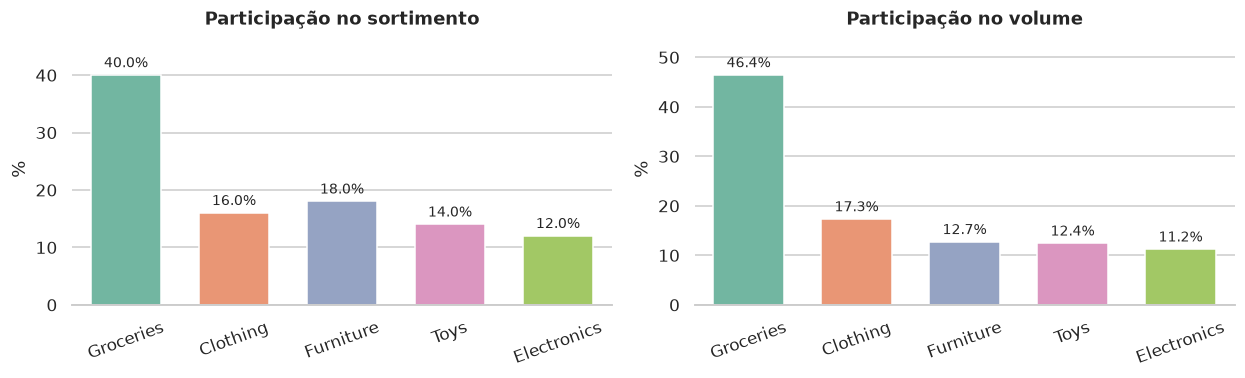

In [4]:
total_dem = vendas["demanda"].sum()

peso = pd.DataFrame({
    "linhas %": (vendas["categoria"].value_counts(normalize=True) * 100).round(1),
    "SKUs": vendas.groupby("categoria")["sku"].nunique(),
    "SKUs %": (vendas.groupby("categoria")["sku"].nunique() / 100 * 100).round(1),
    "% da demanda": (vendas.groupby("categoria")["demanda"].sum() / total_dem * 100).round(1),
}).sort_values("% da demanda", ascending=False)
print(peso.to_markdown(tablefmt="grid"))

ordem_cat = peso.index.tolist()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.6))
for ax, col, tit in [(a1, "SKUs %", "Participação no sortimento"),
                     (a2, "% da demanda", "Participação no volume")]:
    sns.barplot(x=peso.index, y=peso[col], order=ordem_cat, hue=peso.index, hue_order=ordem_cat,
                palette=PALETA, legend=False, width=0.65, ax=ax)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set_title(tit); ax.set_xlabel(""); ax.set_ylabel("%")
    ax.tick_params(axis="x", rotation=20); ax.margins(y=0.18)
sns.despine(left=True)
plt.tight_layout(); plt.show()

**Como ler.** Os dois painéis usam a mesma ordem de categorias. À esquerda, quanto cada uma pesa no **sortimento** (quantos dos 100 SKUs); à direita, quanto pesa no **volume** de demanda. Barras desiguais entre os painéis indicam categorias que puxam mais — ou menos — do que o seu tamanho sugere.

In [5]:
dias_regiao = (vendas.groupby(["data", "regiao"])
               .agg(clima=("clima", "first"), estacao=("estacao", "first")).reset_index())
dias = vendas.groupby("data").agg(estacao=("estacao", "first"), epidemia=("epidemia", "first"))

ordem_cli = ["Sunny", "Cloudy", "Rainy", "Snowy"]
ordem_est = ["Winter", "Spring", "Summer", "Autumn"]

print("Clima — base: 3.040 dias-região (%)")
print((dias_regiao["clima"].value_counts(normalize=True) * 100).reindex(ordem_cli)
      .round(1).to_frame("%").to_markdown(tablefmt="grid"))
print("\nEstação — base: 760 dias (%)")
print((dias["estacao"].value_counts(normalize=True) * 100).reindex(ordem_est)
      .round(1).to_frame("%").to_markdown(tablefmt="grid"))
print(f"\nEpidemia: {int(dias['epidemia'].sum())} dias ({dias['epidemia'].mean():.1%})")
print(f"Promoção: {vendas['promocao'].mean():.1%} das linhas (variável de SKU × dia)")
print(f"\nLojas — participação no volume (%): "
      f"{(vendas.groupby('loja')['demanda'].sum() / total_dem * 100).round(1).to_dict()}")

Clima — base: 3.040 dias-região (%)
+---------+------+
| clima   |    % |
+=========+======+
| Sunny   | 30.2 |
+---------+------+
| Cloudy  | 32.3 |
+---------+------+
| Rainy   | 22.6 |
+---------+------+
| Snowy   | 14.8 |
+---------+------+

Estação — base: 760 dias (%)
+-----------+------+
| estacao   |    % |
+===========+======+
| Winter    | 27.6 |
+-----------+------+
| Spring    | 24.2 |
+-----------+------+
| Summer    | 24.2 |
+-----------+------+
| Autumn    | 23.9 |
+-----------+------+

Epidemia: 152 dias (20.0%)
Promoção: 32.9% das linhas (variável de SKU × dia)

Lojas — participação no volume (%): {'S001': 19.5, 'S002': 20.5, 'S003': 20.4, 'S004': 19.3, 'S005': 20.3}



===== demanda (un./dia) =====
+---------------+---------+
| estatística   |   valor |
+===============+=========+
| média         |  104.32 |
+---------------+---------+
| desvio padrão |   46.96 |
+---------------+---------+
| mínimo        |    4    |
+---------------+---------+
| 1º quartil    |   71    |
+---------------+---------+
| mediana       |  100    |
+---------------+---------+
| 3º quartil    |  133    |
+---------------+---------+
| máximo        |  430    |
+---------------+---------+


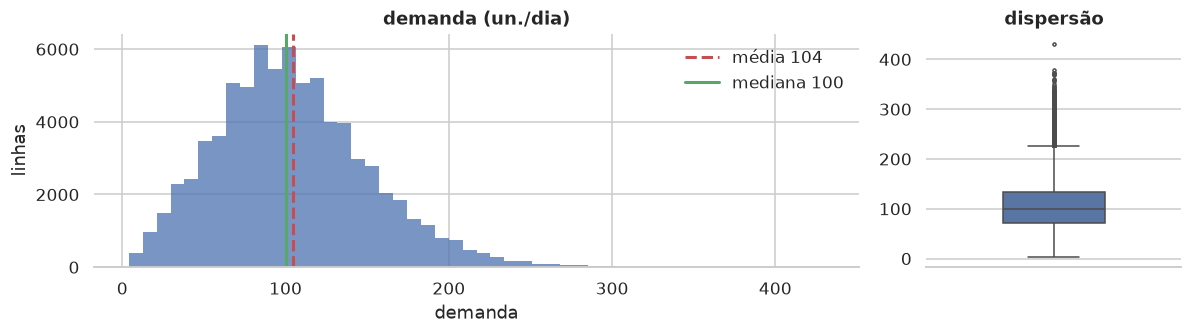


===== vendas (un./dia) =====
+---------------+---------+
| estatística   |   valor |
+===============+=========+
| média         |   88.83 |
+---------------+---------+
| desvio padrão |   43.99 |
+---------------+---------+
| mínimo        |    0    |
+---------------+---------+
| 1º quartil    |   58    |
+---------------+---------+
| mediana       |   84    |
+---------------+---------+
| 3º quartil    |  114    |
+---------------+---------+
| máximo        |  426    |
+---------------+---------+


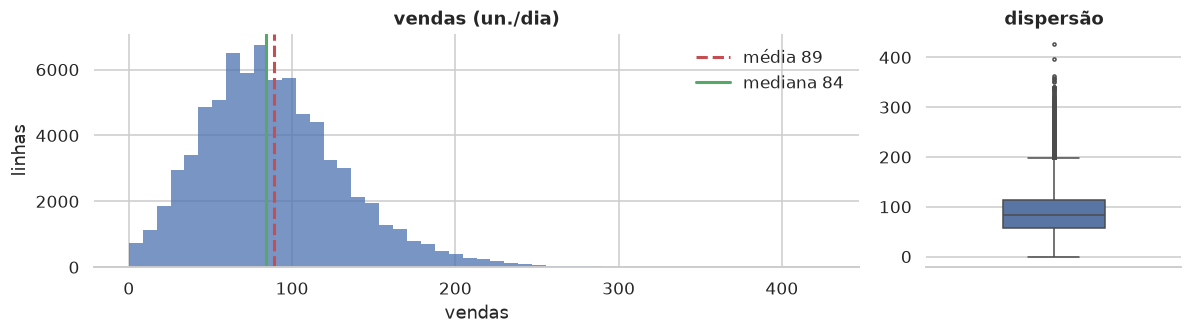


===== estoque (un.) =====
+---------------+---------+
| estatística   |   valor |
+===============+=========+
| média         |  301.06 |
+---------------+---------+
| desvio padrão |  226.51 |
+---------------+---------+
| mínimo        |    0    |
+---------------+---------+
| 1º quartil    |  136    |
+---------------+---------+
| mediana       |  227    |
+---------------+---------+
| 3º quartil    |  408    |
+---------------+---------+
| máximo        | 2267    |
+---------------+---------+


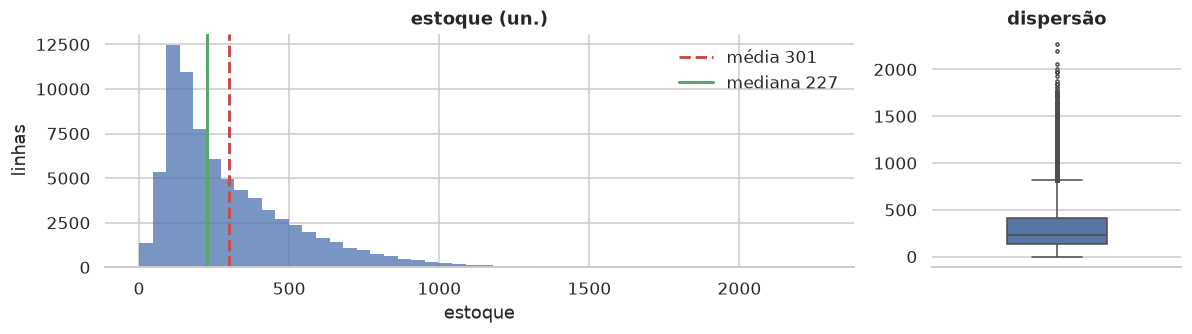


===== preco (R$) =====
+---------------+---------+
| estatística   |   valor |
+===============+=========+
| média         |   67.73 |
+---------------+---------+
| desvio padrão |   39.38 |
+---------------+---------+
| mínimo        |    4.74 |
+---------------+---------+
| 1º quartil    |   32    |
+---------------+---------+
| mediana       |   64.5  |
+---------------+---------+
| 3º quartil    |   95.83 |
+---------------+---------+
| máximo        |  228.03 |
+---------------+---------+


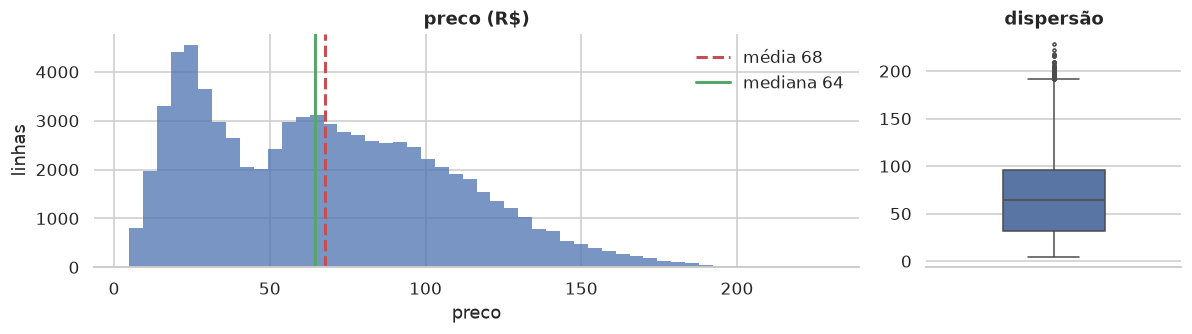

In [6]:
def resumo_numerico(col, unidade="", cor="#4C72B0"):
    s = vendas[col]
    est = pd.DataFrame({"estatística": ["média", "desvio padrão", "mínimo", "1º quartil",
                                        "mediana", "3º quartil", "máximo"],
                        "valor": [s.mean(), s.std(), s.min(), s.quantile(.25),
                                  s.median(), s.quantile(.75), s.max()]}).round(2)
    print(f"\n===== {col} {unidade} =====")
    print(est.to_markdown(index=False, tablefmt="grid"))
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [3, 1]})
    sns.histplot(s, bins=50, color=cor, edgecolor="none", ax=a1)
    a1.axvline(s.mean(), color="#C44E52", lw=2, ls="--", label=f"média {s.mean():.0f}")
    a1.axvline(s.median(), color="#55A868", lw=2, label=f"mediana {s.median():.0f}")
    a1.legend(frameon=False); a1.set_title(f"{col} {unidade}"); a1.set_ylabel("linhas")
    sns.boxplot(y=s, color=cor, width=0.4, ax=a2, fliersize=2)
    a2.set_title("dispersão"); a2.set_ylabel("")
    sns.despine(left=True); plt.tight_layout(); plt.show()


for c, u in [("demanda", "(un./dia)"), ("vendas", "(un./dia)"),
             ("estoque", "(un.)"), ("preco", "(R$)")]:
    resumo_numerico(c, u)

**Como ler.** À esquerda, o histograma: onde a barra é alta, muitos dias têm aquele valor. À direita, o *boxplot*: a caixa contém a metade central dos dados, a linha é a mediana e os pontos soltos são extremos.

A coluna de linhas reproduz a de SKUs, confirmando que contá-las nada acrescenta. No sortimento × volume aparece a informação útil: `Groceries` ocupa 40% dos SKUs e **46% da demanda** (puxa mais do que pesa); `Furniture` faz o inverso (18% → 13%). As cinco lojas são equivalentes em volume (19–21%). A **demanda** é bem-comportada (média 104, mediana 100, leve assimetria à direita), favorável a regressão; as **vendas** são sistematicamente menores (89); e o **preço** varia de R\$ 5 a R\$ 228, o que já indica que comparar preços só faz sentido *dentro* do SKU. A diferença sistemática entre demanda e venda é o assunto da seção 4.

## 4. A mecânica da operação e a natureza do alvo

Há uma objeção séria: **em operação real a demanda não é registrada** — o sistema só conhece o que passou pelo caixa. A demanda é uma variável **latente**, e sua presença aqui é artefato do gerador. Convém então verificar se a coluna `Demand` é coerente e se não seria mais realista modelar as vendas.

In [7]:
restricao = vendas["demanda"] > vendas["estoque"]     # o estoque limitou o dia
excede = vendas["vendas"] > vendas["demanda"]         # logicamente impossível

print("Vendas nunca superam o estoque:", bool((vendas["vendas"] <= vendas["estoque"]).all()),
      "→ `estoque` é a posição de INÍCIO do dia\n")
print(f"Linhas com vendas > demanda: {int(excede.sum())} ({excede.mean():.2%}) — impossível")
print(f"  excedente médio: {(vendas['vendas'] - vendas['demanda'])[excede].mean():.1f} un. "
      f"| máximo: {int((vendas['vendas'] - vendas['demanda']).max())}\n")
print("Onde a incoerência ocorre:")
grupo = restricao.map({False: "estoque NÃO limitou", True: "estoque limitou"})
print(pd.DataFrame({"linhas": grupo.value_counts(),
                    "% com vendas > demanda": (excede.groupby(grupo).mean() * 100).round(1)})
      .to_markdown(tablefmt="grid"))

Vendas nunca superam o estoque: True → `estoque` é a posição de INÍCIO do dia

Linhas com vendas > demanda: 21000 (27.63%) — impossível
  excedente médio: 10.1 un. | máximo: 68

Onde a incoerência ocorre:
+---------------------+----------+--------------------------+
|                     |   linhas |   % com vendas > demanda |
+=====================+==========+==========================+
| estoque NÃO limitou |    65606 |                       32 |
+---------------------+----------+--------------------------+
| estoque limitou     |    10394 |                        0 |
+---------------------+----------+--------------------------+


O resultado delimita o problema. Em **27,6% das linhas a venda supera a demanda** — impossível por definição —, mas isso ocorre **exclusivamente** onde o estoque não restringiu o dia; onde restringiu, nunca. A leitura é direta: o gerador produziu as vendas como `min(demanda, estoque)` e acrescentou ruído apenas no lado livre. **`Demand` é confiável exatamente onde importa** — como teto da venda quando a prateleira limita — e traz ruído de ±10 unidades no restante.

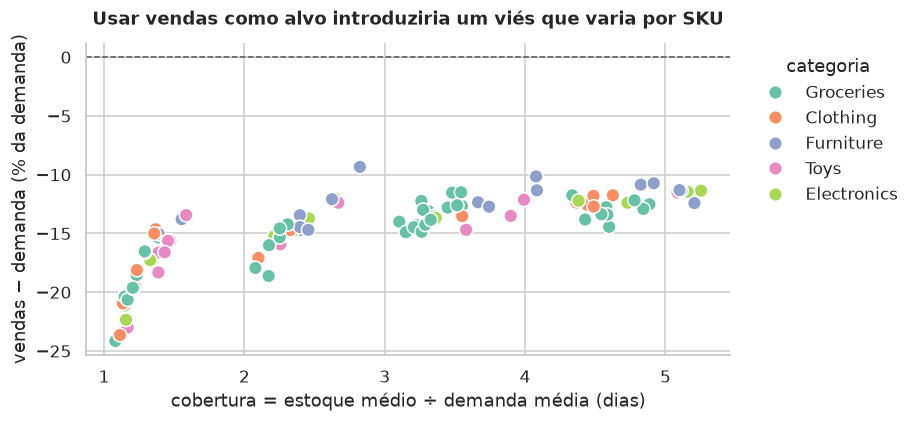

Viés médio da rede: -14.8%
Por SKU — mínimo -24.1% | máximo -9.3% | amplitude 14.8 pontos


In [8]:
vies_sku = (vendas.groupby("sku")["vendas"].sum() / vendas.groupby("sku")["demanda"].sum() - 1) * 100
cob_sku = vendas.groupby("sku")["estoque"].mean() / vendas.groupby("sku")["demanda"].mean()

plt.figure(figsize=(8.5, 4))
ax = sns.scatterplot(x=cob_sku, y=vies_sku, hue=vendas.groupby("sku")["categoria"].first(),
                     hue_order=ordem_cat, palette=PALETA, s=80, edgecolor="white", linewidth=1)
ax.axhline(0, color="#555555", lw=1, ls="--")
ax.set_title("Usar vendas como alvo introduziria um viés que varia por SKU", pad=12)
ax.set_xlabel("cobertura = estoque médio ÷ demanda média (dias)")
ax.set_ylabel("vendas − demanda (% da demanda)")
ax.legend(title="categoria", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine(); plt.tight_layout(); plt.show()

print(f"Viés médio da rede: {(vendas['vendas'].sum() / total_dem - 1) * 100:.1f}%")
print(f"Por SKU — mínimo {vies_sku.min():.1f}% | máximo {vies_sku.max():.1f}% "
      f"| amplitude {vies_sku.max() - vies_sku.min():.1f} pontos")

**Como ler.** Cada ponto é um SKU. No eixo horizontal, a cobertura de estoque em dias; no vertical, quanto as vendas ficam abaixo da demanda, em %. Uma nuvem inclinada mostra que o viés **não é constante** — ele depende de quanto estoque o item costuma ter.

Três conclusões fixam o alvo. **`estoque` é a posição de início do dia** (a venda nunca o supera), o que sustenta toda a análise de ruptura das fases seguintes. A **demanda é latente**, mas fica como alvo: substituí-la pelas vendas introduziria um viés que **varia de −24% a −9% por SKU**, pior onde a cobertura é menor, realimentando o próprio problema (a *espiral descendente da demanda*). E os preditores **`estoque`, `vendas` e `pedidos` ficam de fora** — só existem depois do dia, e usá-los seria vazamento. É essa exclusão que preserva o realismo do exercício.

## 5. O que move a demanda

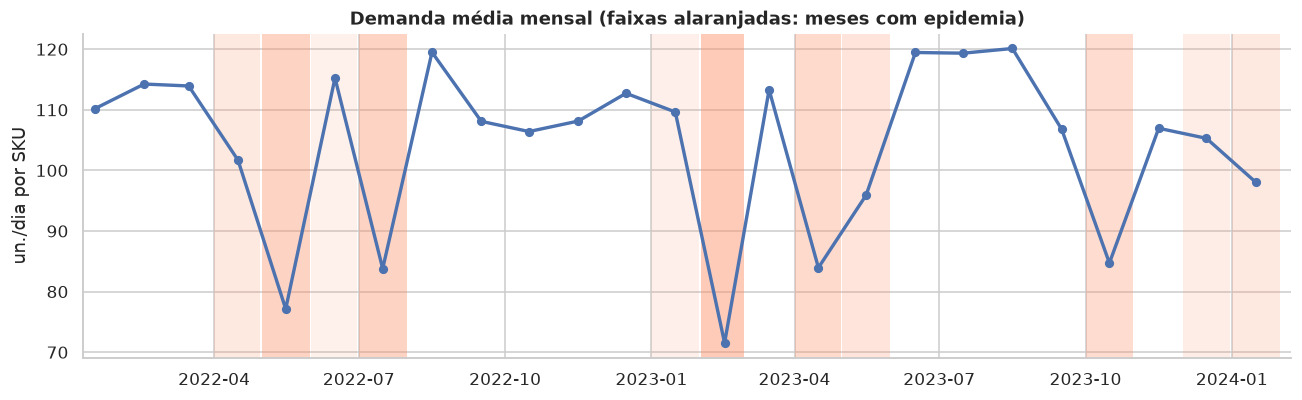

In [9]:
serie = (vendas.groupby(vendas["data"].dt.to_period("M"))
         .agg(demanda=("demanda", "mean"), epidemia=("epidemia", "mean")))
inicio = serie.index.to_timestamp()
serie.index = inicio + pd.Timedelta(days=15)

fig, ax = plt.subplots(figsize=(12, 3.8))
for ini, fr in zip(inicio, serie["epidemia"]):
    if fr > 0:
        ax.axvspan(ini, ini + pd.offsets.MonthEnd(1), color="#FC8D62", alpha=0.10 + 0.35 * fr, lw=0)
ax.plot(serie.index, serie["demanda"], color="#4C72B0", lw=2.2, marker="o", ms=5)
ax.set_title("Demanda média mensal (faixas alaranjadas: meses com epidemia)")
ax.set_ylabel("un./dia por SKU"); ax.margins(x=0.01)
sns.despine(); plt.tight_layout(); plt.show()

**Como ler.** A linha é a demanda média por SKU em cada mês. As faixas alaranjadas marcam meses de epidemia, com tom mais forte quanto maior a fração de dias afetados. Procure duas coisas: se a linha **sobe ou desce ao longo dos dois anos** (tendência) e se os vales coincidem com as faixas.

+-----------+---------+---------+---------------+
| fator     |   menor |   maior |   amplitude % |
+===========+=========+=========+===============+
| categoria |    73.6 |   121   |          64.4 |
+-----------+---------+---------+---------------+
| epidemia  |    70.2 |   112.9 |          60.9 |
+-----------+---------+---------+---------------+
| promoção  |    95   |   123.3 |          29.7 |
+-----------+---------+---------+---------------+
| clima     |    94   |   115.2 |          22.5 |
+-----------+---------+---------+---------------+
| estação   |    97.7 |   112.9 |          15.5 |
+-----------+---------+---------+---------------+


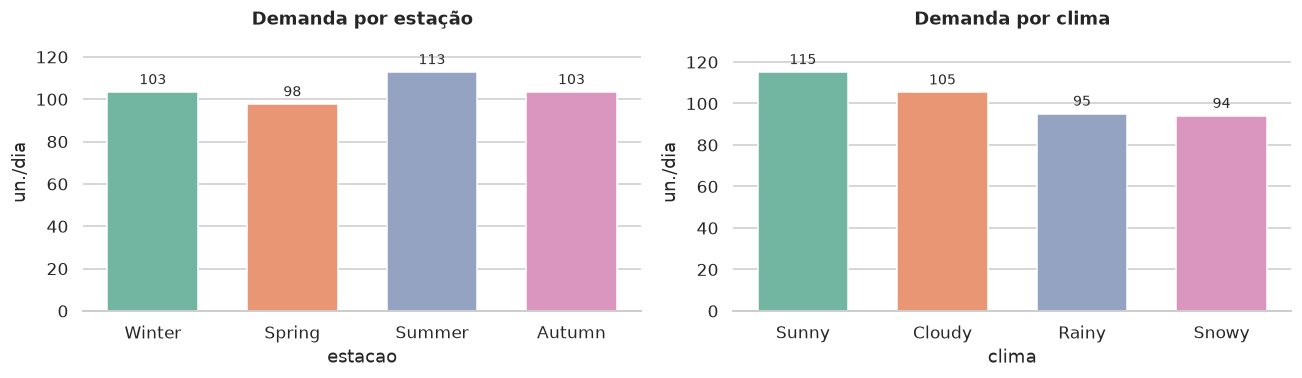

In [10]:
efeitos = []
for col, rot in [("epidemia", "epidemia"), ("promocao", "promoção"),
                 ("clima", "clima"), ("estacao", "estação")]:
    m = vendas.groupby(col)["demanda"].mean()
    efeitos.append({"fator": rot, "menor": round(m.min(), 1), "maior": round(m.max(), 1),
                    "amplitude %": round((m.max() / m.min() - 1) * 100, 1)})
m = vendas.groupby("categoria")["demanda"].mean()
efeitos.append({"fator": "categoria", "menor": round(m.min(), 1), "maior": round(m.max(), 1),
                "amplitude %": round((m.max() / m.min() - 1) * 100, 1)})
print(pd.DataFrame(efeitos).sort_values("amplitude %", ascending=False)
      .to_markdown(index=False, tablefmt="grid"))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, col, ordem, tit in [(axes[0], "estacao", ordem_est, "Demanda por estação"),
                            (axes[1], "clima", ordem_cli, "Demanda por clima")]:
    sns.barplot(data=vendas, x=col, y="demanda", order=ordem, hue=col, hue_order=ordem,
                palette=PALETA, errorbar=None, legend=False, width=0.65, ax=ax)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.0f", padding=3, fontsize=9)
    ax.set_title(tit); ax.set_ylabel("un./dia"); ax.margins(y=0.16)
sns.despine(left=True); plt.tight_layout(); plt.show()

**Como ler.** Cada painel isola um fator e compara a demanda média entre seus níveis. A distância entre a barra mais alta e a mais baixa é o **tamanho do efeito** — é isso, e não a altura absoluta, que interessa.

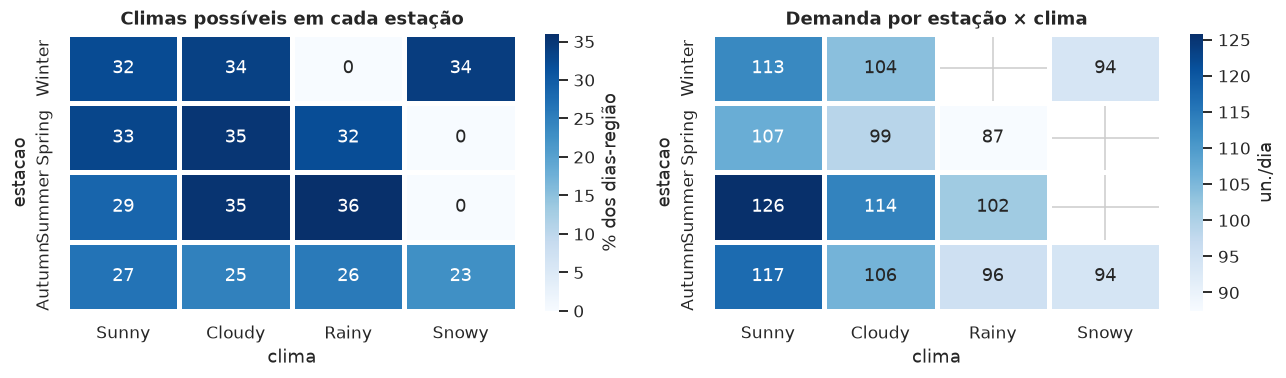

In [11]:
freq = (pd.crosstab(dias_regiao["estacao"], dias_regiao["clima"], normalize="index")
        .loc[ordem_est, ordem_cli] * 100)
media = vendas.pivot_table(index="estacao", columns="clima", values="demanda").loc[ordem_est, ordem_cli]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
sns.heatmap(freq, cmap=SEQ, annot=True, fmt=".0f", linewidths=2, linecolor="white",
            cbar_kws={"label": "% dos dias-região"}, ax=a1)
a1.set_title("Climas possíveis em cada estação")
sns.heatmap(media, cmap=SEQ, annot=True, fmt=".0f", linewidths=2, linecolor="white",
            cbar_kws={"label": "un./dia"}, ax=a2)
a2.set_title("Demanda por estação × clima")
plt.tight_layout(); plt.show()

**Como ler.** Dois mapas de calor com as mesmas linhas (estações) e colunas (climas). O da esquerda mostra **com que frequência** cada combinação ocorre; o da direita, a **demanda média** quando ocorre. Células com 0 à esquerda são combinações que o gerador tornou impossíveis — e por isso a célula correspondente à direita não tem significado.


===== Demanda por categoria, com e sem epidemia =====
+-------------+----------------+----------------+--------------+
| categoria   |   sem epidemia |   com epidemia |   variação % |
+=============+================+================+==============+
| Toys        |          107.4 |           33.5 |        -68.8 |
+-------------+----------------+----------------+--------------+
| Furniture   |           82.6 |           37.5 |        -54.6 |
+-------------+----------------+----------------+--------------+
| Electronics |          107.3 |           58.1 |        -45.9 |
+-------------+----------------+----------------+--------------+
| Groceries   |          130.2 |           83.9 |        -35.6 |
+-------------+----------------+----------------+--------------+
| Clothing    |          112.3 |          113.7 |          1.2 |
+-------------+----------------+----------------+--------------+


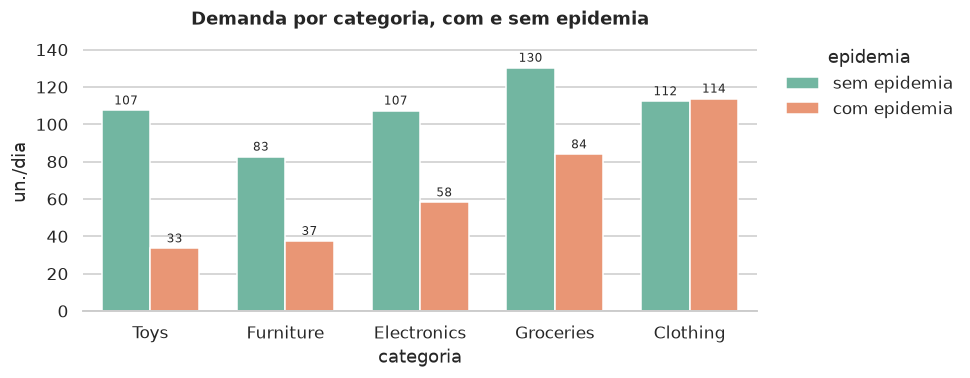


===== Demanda por nível de desconto =====
+------------+----------------+----------------+
|   desconto |   sem promoção |   com promoção |
+============+================+================+
|          0 |           94.7 |          nan   |
+------------+----------------+----------------+
|          5 |           94.9 |          nan   |
+------------+----------------+----------------+
|         10 |           95.4 |          122.5 |
+------------+----------------+----------------+
|         15 |          nan   |          123.6 |
+------------+----------------+----------------+
|         20 |          nan   |          124.1 |
+------------+----------------+----------------+
|         25 |          nan   |          123   |
+------------+----------------+----------------+


In [12]:
def compara(col, rotulos, titulo):
    tab = vendas.pivot_table(index="categoria", columns=col, values="demanda").round(1)
    tab.columns = rotulos
    tab["variação %"] = ((tab[rotulos[1]] / tab[rotulos[0]] - 1) * 100).round(1)
    tab = tab.sort_values("variação %")
    print(f"\n===== {titulo} =====")
    print(tab.to_markdown(tablefmt="grid"))
    plt.figure(figsize=(9, 3.6))
    ax = sns.barplot(data=vendas, x="categoria", y="demanda", hue=col, order=tab.index,
                     palette=PALETA, errorbar=None, width=0.72)
    for c in ax.containers:
        ax.bar_label(c, fmt="%.0f", padding=2, fontsize=8)
    ax.set_title(titulo); ax.set_ylabel("un./dia")
    ax.legend(title=col, labels=rotulos, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.margins(y=0.14)
    sns.despine(left=True); plt.tight_layout(); plt.show()


compara("epidemia", ["sem epidemia", "com epidemia"], "Demanda por categoria, com e sem epidemia")

tab_promo = vendas.pivot_table(index="desconto", columns="promocao", values="demanda", aggfunc="mean")
tab_promo.columns = ["sem promoção", "com promoção"]
print("\n===== Demanda por nível de desconto =====")
print(tab_promo.round(1).to_markdown(tablefmt="grid"))

Fatores em ordem de magnitude:

| fator | efeito | observação |
|---|---|---|
| **epidemia** | 112,9 → 70,2 un. (**−38%**) | o mais forte; 6 surtos de 13 a 33 dias |
| **categoria** | 73,6 → 121,0 un. (**+64%**) | mantimentos contra móveis |
| **promoção** | 95,0 → 123,3 un. (**+30%**) | único fator sob controle da rede |
| **clima** | 94,0 → 115,2 un. (**+23%**) | sol > nublado > chuva ≈ neve |
| **estação** | 97,7 → 112,9 un. (**+16%**) | verão no pico, primavera no vale |

Três achados qualificam essa tabela:

1. **A série não tem tendência** — oscila em torno de 105 unidades nos dois anos. Seus vales são as epidemias, não a sazonalidade.
2. **Clima e estação não são independentes** (2ª marca do gerador): não existe neve na primavera ou no verão, nem chuva no inverno. Isso explica a menor frequência da neve e antecipa que os efeitos "neve" e "inverno" serão difíceis de separar.
3. **A epidemia não atinge as categorias igualmente**: −69% em brinquedos e −55% em móveis (consumo adiável) contra **+1% em roupas**. É uma **interação**, e um modelo puramente aditivo errará nos extremos. Já a promoção é uniforme (+29% a +31%), portanto aditiva.

Sobre o desconto (3ª marca do gerador): sem promoção, variar o desconto de 0% a 10% **não muda a demanda**; com promoção, ela salta para ~123 e fica **constante** em 10%, 15%, 20% ou 25%. O que move a demanda é o **degrau** da promoção, não a magnitude do desconto — e as duas colunas nem são livres entre si.

## 6. O preço: a anomalia em aberto

Falta o fator que a teoria econômica colocaria em primeiro lugar.

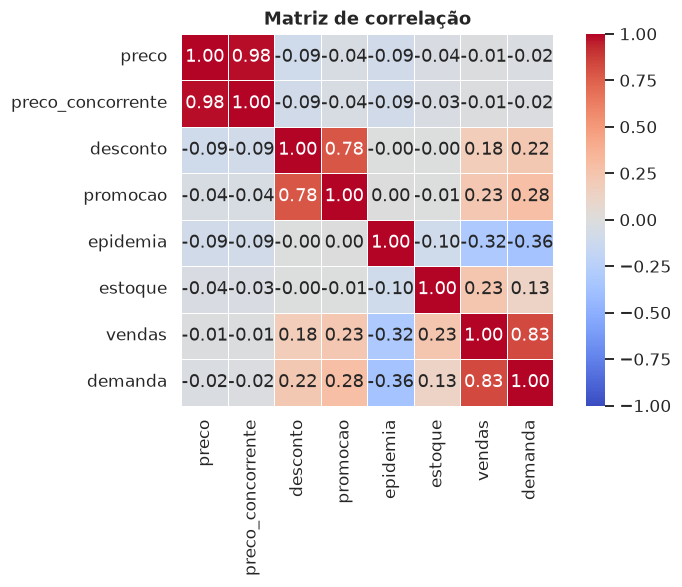

corr(preco, demanda)                     = -0.023
corr(preco, preco_concorrente)           = +0.977
corr(preco - preco_concorrente, demanda) = +0.002


In [13]:
numericas = ["preco", "preco_concorrente", "desconto", "promocao", "epidemia",
             "estoque", "vendas", "demanda"]
plt.figure(figsize=(7.5, 5.5))
sns.heatmap(vendas[numericas].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5, linecolor="white")
plt.title("Matriz de correlação"); plt.tight_layout(); plt.show()

gap = vendas["preco"] - vendas["preco_concorrente"]
print(f"corr(preco, demanda)                     = {vendas['preco'].corr(vendas['demanda']):+.3f}")
print(f"corr(preco, preco_concorrente)           = {vendas['preco'].corr(vendas['preco_concorrente']):+.3f}")
print(f"corr(preco - preco_concorrente, demanda) = {gap.corr(vendas['demanda']):+.3f}")

**Como ler.** Cada célula é a correlação entre duas variáveis, de −1 (azul) a +1 (vermelho). A diagonal é sempre 1. Interessam a **linha da `demanda`** — quem se move junto com ela — e os pares fora da diagonal com cor forte, que indicam variáveis redundantes entre si.

A matriz de correlação revela uma anomalia. **`preco` tem correlação praticamente nula com a demanda (−0,02)**, contra toda a economia elementar. A hipótese mais plausível é que o efeito esteja mascarado pela mistura de faixas de produto — comparar o preço de um móvel com o de um item de mercearia não informa nada —, e só apareça no **preço relativo dentro de cada SKU**. A [Trilha A](05_fase1a_regressaoLinear.ipynb) resolve a questão decompondo o preço em nível do item e desvio do dia. Além disso, **`preco` e `preco_concorrente` são quase colineares (0,977)** e a diferença entre eles não correlaciona com a demanda: o "concorrente" é o próprio preço com ruído, não uma variável competitiva — quarta marca do gerador. Só `epidemia` (−0,36) tem correlação apreciável.

## 7. Síntese

**O que os dados são.** Painel de 100 SKUs × 760 dias, não uma amostra independente: nenhum dos 20 códigos de produto mantém a mesma categoria nas cinco lojas, então só o par `loja + produto` identifica um item. As variáveis são medidas em níveis diferentes (dia, dia × região, SKU × dia), o que define a base de contagem de cada uma; `regiao` duplica `loja` e `estacao` recodifica o mês.

**Origem sintética, confirmada por quatro restrições do gerador.** Ausência total de falhas; ruído de ±10 unidades entre venda e demanda apenas fora da restrição de estoque; impossibilidade de neve fora do inverno e do outono; preço do concorrente derivado do próprio preço (0,977).

**O alvo.** A demanda é latente — não observável em operação real — e mesmo assim se mantém como alvo, porque substituí-la pelas vendas introduziria viés de −24% a −9% conforme o SKU, realimentando o próprio problema. O realismo é preservado pela exclusão de `estoque`, `vendas` e `pedidos` dos preditores, que só existem depois do dia encerrado.

**O que move a demanda.** Em ordem de magnitude: epidemia (−38%), categoria (+64%), promoção (+30%), clima (+23%), estação (+16%). Dois pontos qualificam a lista: a epidemia **não** atinge as categorias igualmente (−69% em brinquedos, +1% em roupas), o que é uma interação e derruba modelos aditivos nos extremos; e o que move a demanda é o degrau da promoção, não o tamanho do desconto.

**Em aberto.** A correlação nula entre preço e demanda (−0,02), contra toda a economia elementar.

---

A diferença sistemática entre demanda e venda — 104,3 contra 88,8 unidades — é cliente não atendido. Quanto isso custa, e como se contrapõe ao capital imobilizado em estoque, é o passo seguinte.